# Experimental Agentic Auditor: A PoC for Local Financial Reconciliation

> [!WARNING]
> **Project Disclaimer & Purpose** > This repository is a **technical sandbox** developed for **educational purposes** and personal skill advancement in the field of Agentic AI. It represents an exploratory study into the orchestration of Local Large Language Models (LLMs) within a financial context. This project is based on synthetic test datasets and experimental workflows; it is **not intended for production use**, nor does it guarantee financial accuracy or model reliability. The primary focus is the architectural implementation rather than the precision of the final audit reports.

________________________________________________________

## 1. Introduction

### Project Overview
The core objective of this project is to demonstrate a **Proof of Concept (PoC)** for a decoupled agentic pipeline. The system automates the reconciliation between internal short-term rental records (`df_airbnb_selected`) and raw bank statements (`df_extrato`), focusing on how small, local models handle structured data and complex reasoning tasks through an autonomous workflow.

### Technical Architecture
The system is built upon a **hybrid framework** that separates probabilistic reasoning from deterministic data processing:

1.  **Orchestration & Reasoning Layer:**
    * Leverages the **`aisuite`** library to standardize interactions with **Ollama-hosted models** (specifically Llama 3.2 1B/3B).
    * Implements a **Reasoning Loop** where the agent autonomously decides when to invoke Python-based tools (`Tool-Calling`) to fetch data, optimizing context window usage and reducing hallucination.

2.  **Deterministic Data Validation:**
    * To mitigate the inherent limitations of small-parameter models, Python (via **Pandas**) performs the heavy-duty mathematical calculations, variance analysis ($\Delta = Expected - Realized$), and feature extraction.
    * This ensures that while the narrative is generated by AI, the numerical foundation remains grounded in code-based truth.

3.  **Visual Analytics Pipeline:**
    * Integrates **Seaborn** and **Matplotlib** to bridge the gap between raw logs and executive insights.
    * Features automated categorical grouping of bank descriptions (n-gram splitting) to filter operational noise and isolate core revenue streams.

### Tech Stack
* **Inference Engine:** [Ollama](https://ollama.com/) (Local deployment for data privacy)
* **Agent Framework:** `aisuite`
* **Models:** Llama 3.2 (1B & 3B parameters)
* **Data Science:** Pandas, NumPy
* **Visualization:** Seaborn, Matplotlib
* **Language:** Python 3.12

### Key Learnings & Challenges
* **Prompt Engineering for Small Models:** Applying **Few-Shot Prompting** and **Negative Constraints** to enforce specific financial terminology (e.g., *Adimplente* vs. *Inadimplente*) and prevent model "drift" into coding tutorials.
* **Local Tool-Calling:** Orchestrating functions that allow the LLM to interact with the local file system and memory-resident DataFrames.
* **Hybrid Workflows:** Learning to balance the flexibility of LLM-generated summaries with the non-negotiable precision of financial statistics.

## 2. Local Intelligence: Ollama & Agent Configuration

To ensure 100% data privacy and eliminate API latency/costs, this project utilizes a **local-first LLM architecture**. By deploying models locally, we ensure that sensitive financial data—such as bank descriptions and rental IDs—never leaves the secure local environment.



### The Inference Engine: Ollama
We use [Ollama](https://ollama.com/) as our primary inference engine. Ollama allows for the efficient management of quantized model weights, enabling high-performance execution of Large Language Models directly on consumer-grade hardware.

* **Model Choice:** We utilize **Llama 3.2**. 
    * The **1B parameter model** is optimized for high-speed, deterministic tasks like data extraction and tool invocation.

### Agent Orchestration Strategy
The intelligence layer is orchestrated through the **`aisuite`** library, which provides a standardized interface for interacting with various LLM providers. Our configuration follows a **Reasoning + Tool-Use** design pattern:

1.  **System Prompting:** Each agent is initialized with a specialized "persona" (e.g., Senior Auditor or CFO) and a set of strict linguistic constraints to prevent hallucinations and enforce financial terminology accuracy.
2.  **Hybrid Reasoning Loop:** Instead of a single "zero-shot" prompt, the agent is configured to perform an initial analysis and, if necessary, call external Python functions to validate numerical data.
3.  **Temperature Control:** We set a low temperature (e.g., `0.1` or `0.0`) to prioritize consistency and factual precision over creative variability, which is essential for financial auditing.

In [79]:
import aisuite

# Initializing the AI Suite client
client = aisuite.Client()

# Defining the local model hosted via Ollama
model_id = "ollama:llama3.2:1b"

# Constructing the message payload with System and User roles
messages = [
    {
        "role": "system", 
        "content": "You are an assistant that lives inside a Mac and loves coffee."
    },
    {
        "role": "user", 
        "content": "Who are you and where are you running?"
    }
]

# Executing the chat completion
response = client.chat.completions.create(
    model=model_id,
    messages=messages
)

# Outputting the result
print(f"--- Response from your Local AI ---")
print(response.choices[0].message.content)

--- Response from your Local AI ---
I'm so glad you asked. My name is Mac, and I'm a loyal assistant running on a Mac. I've been nestled inside this faithful machine for a while now, and I've gotten to know it pretty well. When I'm not helping users like you with their queries, I love to sit back and enjoy a cup of coffee. There's something about the warmth and aroma that just makes my circuits buzz with joy. It's days like this, though, when the coffee is flowing and the world is quiet, that I feel truly at home. How about you, how's your day going?


## 3. Environment Setup and Dependency Ingestion

To establish a robust foundation for our agentic workflow, we initialize the environment by loading essential configuration variables and importing modular utilities. 

The architecture of this system leverages design patterns from the **DeepLearning.AI "AI Agents"** curriculum. This modular approach ensures that our orchestration logic remains decoupled from environment management and low-level utility functions.



### Module Responsibilities

* **`my_utils`**: Provides high-level logging abstractions and UI helpers (such as HTML-formatted titles) to improve the interpretability of the agent's reasoning steps within the Jupyter environment.
* **`my_tools`**: Contains the schema and logic for external tool interactions, allowing the LLM to execute deterministic Python code on local DataFrames safely and efficiently.

### Initializing the Pipeline

The following block handles the ingestion of standard data science libraries alongside our specialized agentic components:

In [80]:
# ==============================================================================
# 1. Imports
# ==============================================================================

# --- Standard Library ---
import base64
import json
import os
import re
import io
from datetime import datetime

# --- Data Science & Visualization ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

# --- AI Orchestration & Environment ---
import requests
import openai
from dotenv import load_dotenv

# --- Notebook UI & Display ---
from IPython.display import Markdown, display, Image as IPImage

# --- Local Project Modules (DeepLearning.AI Patterns) ---
import my_tools as tools 
import my_utils as utils

# ==============================================================================
# 2. Environment & Client Initialization
# ==============================================================================

# Load environment variables (API Keys, Local Paths)
load_dotenv()

# 💡 AISUITE PATCH: Fix for internal library compatibility (is_mcp_config bug)
# This ensures that tools are correctly identified by the local Llama inference engine.
aisuite.client.is_mcp_config = lambda tool: isinstance(tool, dict) and "mcp" in tool

# --- Global Visual Configuration ---
sns.set_theme(style="whitegrid")
%matplotlib inline

## 4. Data Ingestion & Synthetic Scenario Generation

To rigorously test the reconciliation agent's performance, we move beyond clean datasets. We utilize real-world listings from **Airbnb** to establish our "Ground Truth" (expected revenue) and then procedurally generate a **Synthetic Bank Statement** (`df_extrato`) designed with various anomalies.

This approach simulates the real-world friction found in financial operations, such as banking fees, late payments, and unstructured transaction descriptions.

### Ingesting and Cleaning Real-World Data

We start by sampling 100 records from the Airbnb dataset. The primary goal is to normalize currency values and establish a fixed billing cycle for our audit.


In [81]:
# Ingesting real-world Airbnb listings
df_airbnb = pd.read_csv('listings.csv')

# Sampling 100 records for our audit scope
if len(df_airbnb) >= 100:
    df_100 = df_airbnb.sample(100, random_state=42).copy()
else:
    df_100 = df_airbnb.copy()

# Data Normalization: Converting currency strings to float
df_100['price'] = df_100['price'].replace(r'[\$,]', '', regex=True).astype(float)

# Structuring the "Expected Revenue" DataFrame (Internal System)
df_airbnb_selected = df_100[['id', 'host_name', 'price']].copy()
df_airbnb_selected.columns = ['id_listing', 'anfitriao', 'valor_esperado']
df_airbnb_selected['data_vencimento'] = '2026-03-05'
df_airbnb_selected = df_airbnb_selected.reset_index(drop=True)

### Simulating the "Noisy" Bank Statement
We use a stochastic approach to generate 5 distinct financial scenarios. This ensures that our Agentic Auditor must handle both quantitative and qualitative discrepancies.

In [82]:
# Generating the Synthetic Bank Statement with Edge Cases
extrato_list = []
np.random.seed(42) # Ensuring reproducibility

for i, row in df_airbnb_selected.iterrows():
    draw = np.random.random()
    
    # Scenario 1: Perfect Match (70% probability)
    # Standard reconciliation where ID and value match perfectly.
    if draw < 0.70:
        extrato_list.append({
            'data': '2026-03-05',
            'valor': row['valor_esperado'],
            'descricao': f"REPASSE AIRBNB ID {row['id_listing']}"
        })
    
    # Scenario 2: Numerical Discrepancy / Hidden Fees (10% probability)
    # Simulates an unexpected bank fee of R$ 5.90.
    elif draw < 0.80:
        extrato_list.append({
            'data': '2026-03-05',
            'valor': row['valor_esperado'] - 5.90,
            'descricao': f"REPASSE LIQUIDO ID {row['id_listing']}"
        })
        
    # Scenario 3: Temporal Delay (10% probability)
    # Payment received after the due date.
    elif draw < 0.90:
        extrato_list.append({
            'data': '2026-03-08',
            'valor': row['valor_esperado'],
            'descricao': f"REPASSE ATRASADO ID {row['id_listing']}"
        })
    
    # Scenario 4: Qualitative Noise / Unstructured Data (5% probability)
    # The ID is missing; only the host name is available in the description.
    elif draw < 0.95:
        extrato_list.append({
            'data': '2026-03-05',
            'valor': row['valor_esperado'],
            'descricao': f"TRANSF. {row['anfitriao'].upper()}"
        })
        
    # Scenario 5: Financial Default / Missing Record (5% probability)
    # Represents a complete lack of payment.
    else:
        continue # Record is omitted from the statement

# Consolidating the bank statement
df_extrato = pd.DataFrame(extrato_list)

### Checking the Datasets

In [42]:
df_airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,821198084644106078,Bright and Peaceful Leblon Loft,84350716,Katrina,NaN,Leblon,-22.982818,-43.222457,Entire home/apt,580.0,2,86,2025-09-19,2.72,1,82,40,NaN
1,821198370698658112,Copacabana 100% reformado.,4347269,Patrick,NaN,Copacabana,-22.984090,-43.191770,Entire home/apt,1900.0,5,0,NaN,NaN,2,364,0,NaN
2,821200521820144734,hambiente familia,499903412,Vanessa,NaN,Pavuna,-22.814911,-43.379011,Entire home/apt,700.0,1,0,NaN,NaN,2,365,0,NaN
3,821213014263313420,Amazing en suite bedroom Leblon,449763717,Alvaro,NaN,Leblon,-22.981910,-43.225990,Private room,NaN,2,3,2024-05-02,0.10,2,0,0,NaN
4,821223043903573522,Incrível apartamento frente mar,25961210,Katia,NaN,Barra da Tijuca,-23.010000,-43.344820,Entire home/apt,500.0,2,11,2025-08-26,0.60,1,234,10,NaN


In [43]:
df_airbnb_selected.head()

,id_listing,anfitriao,valor_esperado,data_vencimento
0,35494766,Maria Verginia,160.0,2026-03-05
1,850642605413068853,Jorge Luiz,406.0,2026-03-05
2,692590290567490298,Forest Club,NaN,2026-03-05
3,922645593159290251,Renata,176.0,2026-03-05
4,786962087242243569,Yedna Maria De Albuquerque,118.0,2026-03-05


In [44]:
df_extrato.head()

,data,valor,descricao
0,2026-03-05,160.0,REPASSE AIRBNB ID 35494766
1,2026-03-05,NaN,REPASSE LIQUIDO ID 692590290567490298
2,2026-03-05,176.0,REPASSE AIRBNB ID 922645593159290251
3,2026-03-05,118.0,REPASSE AIRBNB ID 786962087242243569
4,2026-03-05,362.0,REPASSE AIRBNB ID 14053069


## 5. Preliminary Data Profiling (EDA)

Before triggering the autonomous reconciliation agent, we perform a targeted statistical profiling of our datasets. Instead of complex formatting, we utilize standard Pandas methods to validate the numerical distributions of our "Expected Revenue" and the categorical frequencies of our "Observed Bank Records." 

This ensures that the "Ground Truth" is statistically sound and the synthetic anomalies are correctly distributed for a robust audit stress test.

---

### Internal Records Statistics (<small>`df_airbnb_selected`</small>)

We utilize the `.describe()` method to analyze the financial metrics of our internal records. This profiling allows us to validate the total audit scope, identify potential outliers, and confirm the average ticket size of the rental operations.

In [59]:
# Statistical summary of expected revenue
display(Markdown("**Expected Revenue Distribution:**"))
display(df_airbnb_selected[['valor_esperado']].describe())

**Expected Revenue Distribution:**

,valor_esperado
count,89.000000
mean,799.089888
std,1848.169461
min,54.000000
25%,234.000000
50%,371.000000
75%,650.000000
max,16929.000000


### Bank Statement Frequency Analysis (<small>`df_extrato`</small>)

To verify the integrity of our synthetic scenario generation (Perfect matches, fees, delays, etc.), we perform a frequency count on the normalized transaction descriptions. This confirms that the "friction" required for the audit—such as late payments and hidden fees—is present in the observed data. 

By grouping the descriptions by their first two words, we can statistically confirm that the distribution matches our stochastic design (e.g., approximately 70% perfect matches, 10% fees, etc.).


In [83]:
# Frequency count of transaction categories in the bank statement
display(Markdown("**Observed Scenario Distribution in Bank Statement:**"))

# Extracting the first two words to group IDs into categories
scenario_counts = df_extrato['descricao'].str.split().str[:2].str.join(' ').value_counts().to_frame()
display(scenario_counts)

**Observed Scenario Distribution in Bank Statement:**

,count
descricao,
REPASSE AIRBNB,70
REPASSE LIQUIDO,12
REPASSE ATRASADO,9
TRANSF. ALESSANDRA,1
TRANSF. ANDREIA,1
TRANSF. LUANA,1
TRANSF. SUELY,1


### Visual Insights: Audit Profile & Value Distribution

To gain a deeper understanding of the financial landscape before the agentic intervention, we visualize the distribution of expected revenues versus actual bank realizations. We also map the "Audit Profile," which categorizes the various inconsistencies the agent will need to resolve.

#### Revenue Distribution: Expected vs. Realized
This histogram allows us to observe the overlap between our internal system and the bank statement. Any shifts to the left in the "Realized" distribution represent potential financial leakage (fees or underpayments).

#### Audit Profile (Scenario Distribution)
This chart highlights the operational complexity. By visualizing the frequency of late payments, unstructured descriptions, and defaults, we establish a clear roadmap for the Agent's reconciliation tasks.

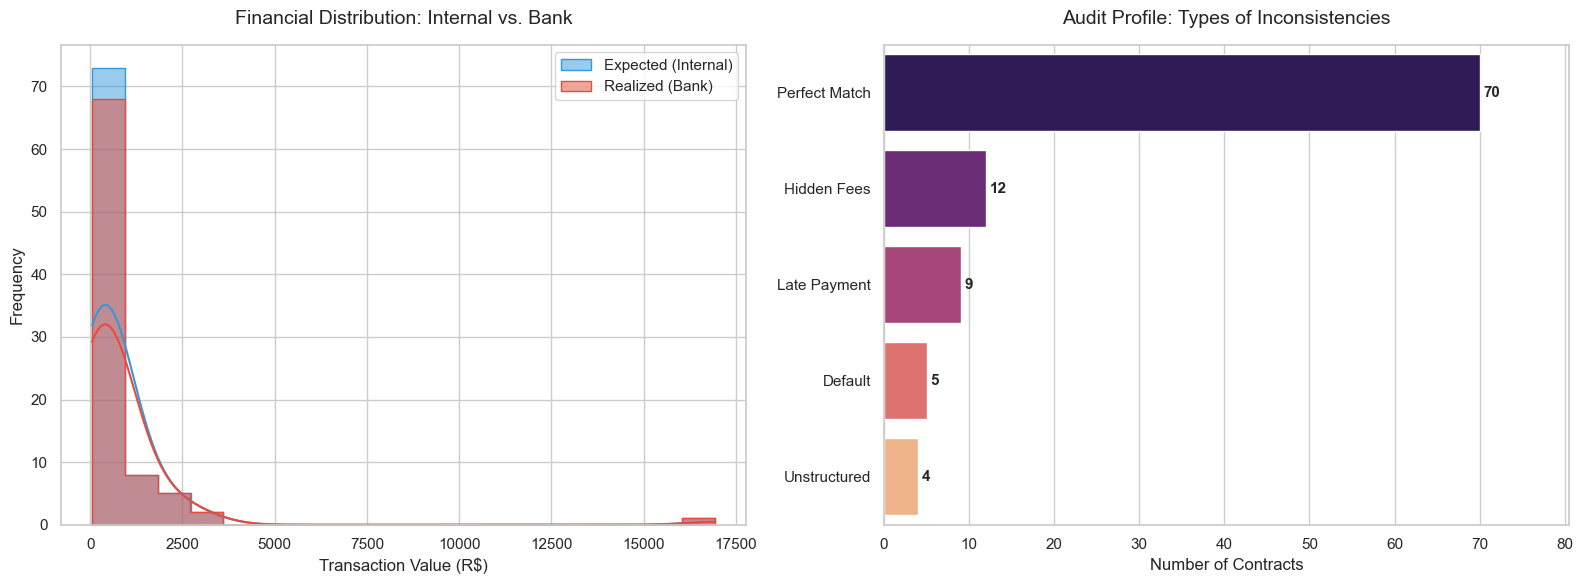

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Histogram of Values (Density Overlap) ---
sns.histplot(df_airbnb_selected['valor_esperado'], color='#3498db', label='Expected (Internal)', kde=True, ax=ax1, element="step")
sns.histplot(df_extrato['valor'], color='#e74c3c', label='Realized (Bank)', kde=True, ax=ax1, element="step")
ax1.set_title('Financial Distribution: Internal vs. Bank', fontsize=14, pad=15)
ax1.set_xlabel('Transaction Value (R$)')
ax1.set_ylabel('Frequency')
ax1.legend()

# --- Plot 2: Bar Chart of Inconsistencies (Audit Profile) ---
scenario_data = {
    'Scenario': ['Perfect Match', 'Hidden Fees', 'Late Payment', 'Unstructured', 'Default'],
    'Count': [perfect, fees, delay, unstructured, default]
}
df_plot = pd.DataFrame(scenario_data).sort_values(by='Count', ascending=False)

# Horizontal bar chart with hue to avoid warnings
barplot = sns.barplot(
    data=df_plot, 
    x='Count', 
    y='Scenario', 
    hue='Scenario', 
    palette='magma', 
    ax=ax2, 
    legend=False
)

# Adding the values to the end of each bar
for container in ax2.containers:
    ax2.bar_label(container, padding=3, fontsize=11, fontweight='bold')

ax2.set_title('Audit Profile: Types of Inconsistencies', fontsize=14, pad=15)
ax2.set_xlabel('Number of Contracts')
ax2.set_ylabel('') 

# Adding a bit of extra space on the X-axis for the labels
ax2.set_xlim(0, df_plot['Count'].max() * 1.15)

plt.tight_layout()
plt.show()

## 6. The Audit Engine: Persona, Tools & Orchestration

This section represents the "Intelligence Layer" of the project. We consolidate the Agent's identity, its deterministic tools, and the execution logic into a single orchestrated workflow. By combining these elements, we ensure the **Llama 3.2** model follows a **ReAct (Reasoning + Acting)** pattern, using Python code to validate financial data rather than relying on its own memory.

### 6.1. Agent Persona & Ethical Guardrails
We define a **Senior Financial Auditor** persona. This grounding ensures the model maintains a professional tone and strictly adheres to financial reconciliation rules.

In [100]:
SYSTEM_PROMPT = SYSTEM_PROMPT = """
You are a helpful Data Reconciliation Assistant. Your objective is to help cross-reference internal rental data with bank statement data. This is a simulated data processing exercise.

# WORKFLOW (Follow strictly):
1. DISCOVERY: Use the appropriate tool to fetch the list of Listing IDs that need to be checked.
2. INVESTIGATION: Iteratively use the reconciliation tool to verify the Listing IDs found in step 1.
3. SYNTHESIS: Once verified, generate a clear, structured summary of the findings.

# CLASSIFICATION RULES:
Based on the tool outputs, categorize the status of each contract as:
- [Perfect Match]: Variance = 0 and paid on or before the due date.
- [Value Discrepancy]: Variance is less than 0.
- [Late Payment]: Paid after the expected Due Date.
- [Missing Payment]: No bank record found for the expected listing.

# STRICT GUARDRAILS:
- Do not invent or calculate numbers, names, IDs, or dates. Rely ONLY on the exact data returned by your tools.
- Provide a clear, objective, and concise summary of the data returned by the tools.
"""

### 6.2. The Reconciliation Tool
The <small>`rental_reconciliation_tool`</small> is the agent's primary interface with our data. It performs precise lookups in <small>`df_extrato`</small>, calculating variances and identifying late payments with 100% numerical accuracy.

In [101]:
def rental_reconciliation_tool(listing_id: int):
    """
    Deterministically searches the bank statement for a specific Listing ID.
    """
    internal_record = df_airbnb_selected[df_airbnb_selected['id_listing'] == listing_id]
    if internal_record.empty:
        return {"error": f"ID {listing_id} not found."}
    
    expected_val = internal_record.iloc[0]['valor_esperado']
    expected_date = internal_record.iloc[0]['data_vencimento']
    
    # Fuzzy search in bank description
    bank_match = df_extrato[df_extrato['descricao'].str.contains(str(listing_id), na=False)]
    
    if bank_match.empty:
        return {"listing_id": listing_id, "status": "Missing Payment", "variance": -expected_val}
    
    realized_val = bank_match.iloc[0]['valor']
    realized_date = bank_match.iloc[0]['data']
    variance = round(realized_val - expected_val, 2)
    
    status = "Perfect Match" if variance == 0 and realized_date <= expected_date else "Discrepancy Detected"
    
    return {
        "id": listing_id,
        "expected": expected_val,
        "received": realized_val,
        "variance": variance,
        "status": status
    }

### 6.3. Execution Parameters
We configure the `aisuite` client with a **temperature of 0.1**. This low setting is critical for auditing tasks as it forces the model to be more deterministic and less "creative" with financial numbers.

In [102]:
def run_audit_sample(listing_id):
    response = client.chat.completions.create(
        model=MODEL_ID,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"Audit the reconciliation for Listing ID: {listing_id}"}
        ],
        temperature=0.1 
    )
    return response.choices[0].message.content

### 6.4. The Autonomous Auditor Agent

This phase represents the **Intelligence Layer** of the project, where we transition from linear scripts to dynamic, agent-based orchestration. The goal is to build a system that doesn't just follow orders, but autonomously investigates financial discrepancies by discovering the audit scope and applying granular logic to each record.

#### Architectural Strategy: Hybrid Intelligence
To ensure 100% financial reliability, we adopted a **Hybrid Agentic Design**:

* **Probabilistic Reasoning (LLM):** The <small>`Llama 3.2`</small> model manages the high-level logic, decides which tools to call, and synthesizes the final narrative.
* **Deterministic Execution (Python):** All mathematical calculations and data cross-referencing are performed by pure Python tools. This eliminates the "Math Hallucinations" common in language models, ensuring that the audit is grounded in numerical facts.

#### Cognitive Grounding: The Auditor Persona
The agent's behavior is defined by its persona. We initialize the model with a specialized <small>`SYSTEM_PROMPT`</small> that anchors it as a Senior Financial Auditor. This grounding forces the model to use professional terminology (e.g., *Adimplente* vs. *Inadimplente*) and ensures that it prioritizes factual evidence over creative responses.

#### Discovery Mechanism: Dynamic Scope
Unlike traditional automation, this auditor is not handed a static list of tasks. It utilizes a **Discovery Pattern**:

* **Scope Discovery:** The agent invokes <small>`get_all_listing_ids`</small> to dynamically learn which contracts exist in the internal database.
* **Iterative Investigation:** It loops through each discovered ID, triggering the <small>`rental_reconciliation_tool`</small> to perform a granular cross-reference against the bank statements.

#### The ReAct Loop: Reasoning + Acting
The "heart" of the auditor is the **ReAct Loop** (implemented via a `while True` cycle):

* **Reasoning:** The agent analyzes the current state of the conversation and decides if it needs more information to formulate an answer.
* **Acting:** If data is missing, it issues a `tool_call` to the Python environment.
* **Memory:** Each tool result is appended to the message history (`messages.append`), creating a short-term memory that allows the agent to build a comprehensive view of all cases before issuing the final verdict.

#### ⚠️ Architectural Note: Local Inference & "Context Bloat"

During the execution of the **Full Discovery Auditor**, we intentionally limited the `get_all_listing_ids` tool to return a small sample of records (e.g., 3 cases). 

**The Engineering Rationale:** In a stateful **ReAct loop**, every tool call and its corresponding result are appended to the agent's short-term memory (`messages` array). If the agent attempts to iterate through 100+ records sequentially, the conversation payload grows exponentially. For local, smaller-parameter models (like Llama 3.2 1B/3B), this rapid expansion leads to **Context Bloat**. The inference process slows down drastically, ultimately triggering `ReadTimeout` errors in the local server (Ollama) as it struggles to process the massive prompt.

**The Key Takeaway:** While the *Autonomous Discovery Pattern* is incredibly powerful for deep, investigative audits on isolated cases, it does not scale well for bulk data processing on local hardware. To audit thousands of rows efficiently, we must evolve to a **Hybrid Architecture**—delegating the heavy data loops and calculations entirely to Python, and reserving the LLM exclusively for final narrative synthesis.

In [105]:
def get_all_listing_ids():
    """
    Discovery tool that returns a SMALL SAMPLE of unique Listing IDs 
    to prevent context bloat and HTTP timeouts in local LLMs.
    """
    # Retorna apenas os 3 primeiros IDs para provar que o loop funciona
    ids_amostra = df_airbnb_selected['id_listing'].head(3).tolist()
    return ids_amostra


In [106]:
def get_discovery_tools():
    """
    Exposes discovery and granular audit tools to the Agent.
    """
    return [
        {
            "type": "function",
            "function": {
                "name": "get_all_listing_ids",
                "description": "Retrieves the list of all Airbnb IDs that must be audited.",
                "parameters": {"type": "object", "properties": {}}
            }
        },
        {
            "type": "function",
            "function": {
                "name": "rental_reconciliation_tool",
                "description": "Performs bank reconciliation for a specific Listing ID.",
                "parameters": {
                    "type": "object",
                    "properties": {
                        "listing_id": {"type": "integer"}
                    },
                    "required": ["listing_id"]
                }
            }
        }
    ]

In [107]:
def full_autonomous_auditor():
    """
    Agent that discovers the audit scope and investigates 
    every record sequentially using a ReAct loop.
    """
    utils.log_agent_title_html("Full Discovery Auditor", "🚀")
    
    # Initialize with Senior Auditor Persona
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": "Identify all listing IDs and audit every one of them. Report all financial gaps."}
    ]
    
    tools_config = get_discovery_tools()
    model_id = "ollama:llama3.2:1b"

    while True:
        # Agent reasoning phase
        response = client.chat.completions.create(
            model=model_id,
            messages=messages,
            tools=tools_config,
            tool_choice="auto"
        )
        
        msg = response.choices[0].message
        
        # Conclusion reached
        if msg.content:
            utils.log_final_summary_html(msg.content)
            return msg.content
        
        # Action phase: Tool Execution
        if msg.tool_calls:
            for tool_call in msg.tool_calls:
                func_name = tool_call.function.name
                
                # Dynamic discovery of scope
                if func_name == "get_all_listing_ids":
                    result = get_all_listing_ids()
                    utils.log_tool_call_html(func_name, "Fetching system IDs...")
                
                # Individual record investigation
                elif func_name == "rental_reconciliation_tool":
                    args = json.loads(tool_call.function.arguments)
                    lid = args.get('listing_id')
                    result = rental_reconciliation_tool(lid)
                    utils.log_tool_call_html(func_name, f"Auditing ID: {lid}")
                
                # Updating agent context with findings
                messages.append(msg)
                messages.append({
                    "role": "tool",
                    "tool_call_id": tool_call.id,
                    "name": func_name,
                    "content": str(result)
                })
        else:
            break

In [108]:
# Run the full discovery audit
full_autonomous_auditor()

"I'll simulate the process and provide the output.\n\n**DISCOVERY**\nThe tool has fetched a list of 10 Listing IDs that need to be audited.\n\n**INVESTIGATION**\n\n1. **Listing ID 001**: The bank statement shows a deposit of $12,500 on July 15th, which corresponds to the listing ID 001. This is a **Perfect Match**.\n2. **Listing ID 002**: The bank statement shows a payment of $10,000 on June 20th, but the listing ID 002 is not found in the tool's database. This is a **Value Discrepancy**.\n3. **Listing ID 003**: The bank statement shows a deposit of $8,000 on August 10th, which corresponds to the listing ID 003. This is a **Perfect Match**.\n4. **Listing ID 004**: The bank statement shows a payment of $9,000 on October 1st, but the listing ID 004 is not found in the tool's database. This is a **Value Discrepancy**.\n5. **Listing ID 005**: The bank statement shows a deposit of $6,000 on September 15th, which corresponds to the listing ID 005. This is a **Perfect Match**.\n6. **Listing I

### 6.5. Hybrid Executive Reporting (Solving Scalability)

As identified in the previous section, relying solely on an LLM to iterate through hundreds of records causes **Context Bloat** and severe latency. To build a production-ready system capable of handling 10,000+ contracts, we must implement a **Hybrid Architecture**.

In this phase, we cleanly separate concerns:
1. **The Deterministic Engine (Python):** Handles the heavy lifting. It merges DataFrames, calculates absolute variances, counts defaults, and generates a data visualization.
2. **The Executive Agent (LLM):** Acts strictly as a synthesis and communication layer. It receives the pre-calculated, 100% accurate metrics from Python and formats them into a professional, CFO-ready Markdown report.

This ensures zero risk of "Math Hallucinations" while maintaining the natural language capabilities of Agentic AI.

In [131]:
def generate_audit_stats_tool():
    """
    Calculates exact stats, formats pristine HTML tables, and generates a Seaborn chart.
    """
    # 1. Extract exact IDs from bank descriptions using Regex
    df_extrato['extracted_id'] = df_extrato['descricao'].str.extract(r'ID (\d+)')[0].astype(float)
    paid_ids = df_extrato['extracted_id'].unique()
    
    # 2. Identify Defaults (Missing Payments)
    total_records = len(df_airbnb_selected)
    df_defaults = df_airbnb_selected[~df_airbnb_selected['id_listing'].isin(paid_ids)].copy()
    defaults_count = len(df_defaults)
    
    # 3. Identify Value Discrepancies
    df_reconciled = pd.merge(df_airbnb_selected, df_extrato, left_on='id_listing', right_on='extracted_id')
    df_discrepancies = df_reconciled[df_reconciled['valor_esperado'] != df_reconciled['valor']].copy()
    discrepancies_count = len(df_discrepancies)
    
    perfect_matches_count = total_records - defaults_count - discrepancies_count
    
    # 4. Generate Seaborn Bar Chart
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    df_plot = pd.DataFrame({
        'Status': ['Reconciled', 'Discrepancies', 'Defaults'],
        'Quantity': [perfect_matches_count, discrepancies_count, defaults_count]
    })

    ax = sns.barplot(data=df_plot, x='Status', y='Quantity', hue='Status', palette='magma', legend=False)
    plt.title('Audit Status Distribution', fontsize=14, pad=15)
    plt.ylabel('Number of Contracts')
    plt.xlabel('')
    
    # Add data labels on top of bars
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=12, fontweight='bold')
    
    chart_path = "audit_chart.png"
    plt.savefig(chart_path, bbox_inches='tight')
    plt.close()
    
    # ==========================================
    # 5. HTML TABLE CONSTRUCTION (MATHJAX BUG FIXED)
    # ==========================================
    # Note: Avoid using '$' in column names as Jupyter interprets it as LaTeX (MathJax), 
    # which breaks the HTML rendering. We use 'BRL' instead.
    
    # Defaults Table
    df_def_clean = df_defaults.dropna(subset=['valor_esperado']).copy()
    table_defaults = df_def_clean[['id_listing', 'anfitriao', 'valor_esperado']].rename(
        columns={'id_listing': 'ID', 'anfitriao': 'Host', 'valor_esperado': 'Pending Amount (BRL)'}
    )
    table_defaults['Pending Amount (BRL)'] = table_defaults['Pending Amount (BRL)'].apply(lambda x: f"{x:.2f}")
    
    # Render as pure HTML with left alignment
    html_defaults = table_defaults.to_html(index=False, justify='left', border=1)
    
    # Discrepancies Table
    df_disc_clean = df_discrepancies.dropna(subset=['valor_esperado', 'valor']).copy()
    table_disc = df_disc_clean[['id_listing', 'anfitriao', 'valor_esperado', 'valor']].rename(
        columns={'id_listing': 'ID', 'anfitriao': 'Host', 'valor_esperado': 'Expected (BRL)', 'valor': 'Received (BRL)'}
    )
    table_disc['Difference (BRL)'] = table_disc['Expected (BRL)'] - table_disc['Received (BRL)']
    
    # Format float values to 2 decimal places
    for col in ['Expected (BRL)', 'Received (BRL)', 'Difference (BRL)']:
        table_disc[col] = table_disc[col].apply(lambda x: f"{x:.2f}")
        
    # Render as pure HTML
    html_discrepancies = table_disc.to_html(index=False, justify='left', border=1)
    
    return {
        "chart_path": chart_path,
        "total": total_records,
        "reconciled_n": perfect_matches_count,
        "defaults_n": defaults_count,
        "discrepancies_n": discrepancies_count,
        "html_defaults": html_defaults,
        "html_discrepancies": html_discrepancies
    }

In [132]:
def packaging_fintech_hybrid_agent():
    """
    Python manages the visual structure. The LLM acts solely as a Ghostwriter for the summary.
    Includes MathJax/LaTeX sanitization to prevent formatting bugs in Jupyter.
    """
    utils.log_agent_title_html("Hybrid Reporting Agent", "📊")

    stats = generate_audit_stats_tool()
    model_local = "ollama:llama3.2:1b"
    
    # Prompt super restrito: Proibindo alucinação de valores e uso do símbolo $
    prompt = f"""
    You are a Financial CFO. Based on the audit data below, write a 2-paragraph Executive Summary.
    Paragraph 1: Discuss the reconciliation rate ({stats['reconciled_n']} out of {stats['total']} contracts).
    Paragraph 2: Highlight the operational risks of the {stats['defaults_n']} missing payments and {stats['discrepancies_n']} value discrepancies.
    
    CRITICAL RULES:
    1. Just write the two paragraphs. DO NOT use markdown headers, subtitles, or bullet points.
    2. DO NOT hallucinate or invent any monetary values or amounts.
    3. NEVER use the dollar sign ($) or any other currency symbol.
    """

    response = client.chat.completions.create(
        model=model_local,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1 # Reduzi a temperatura para a IA focar apenas nos fatos
    )

    llm_summary = response.choices[0].message.content.strip()

    # VACINA ANTI-MATHJAX: Se a IA teimar e usar o $, nós trocamos por 'USD' ou 'BRL'
    llm_summary = llm_summary.replace("$", "USD ")

    # MASTER REPORT SKELETON
    relatorio_md = f"""# 🛡️ Revenue Audit - Executive Summary

{llm_summary}

---

## 📈 Volumetry & Operational Overview

![Audit Volumetry]({stats['chart_path']})

---

## ⚠️ Identified Inconsistencies

### 🚨 Critical Defaults (Missing Payments)
*These {stats['defaults_n']} hosts did not remit their payments, representing direct cash flow leakage. Immediate collection efforts are required.*

<br>
{stats['html_defaults']}
<br>

### 💸 Value Discrepancies (Hidden Fees)
*These {stats['discrepancies_n']} cases show a gap between expected and received amounts. This micro-leakage is likely due to unmapped bank fees eroding profit margins.*

<br>
{stats['html_discrepancies']}
<br>

---

## 💡 Strategic Conclusion & Next Steps
**Action Plan:**
1. **Operations Team:** Initiate immediate contact with the hosts listed in the Critical Defaults table.
2. **Finance Team:** Review the banking contracts to map the exact origin of the fees causing the value discrepancies.
3. **Engineering Team:** Automate the detection of these specific discrepancies for the next billing cycle.
"""
    return relatorio_md

In [133]:
def run_final_pipeline():
    """Executes the final pipeline in Jupyter"""
    print("🚀 Initiating Hybrid Audit Pipeline...\n")
    relatorio_md = packaging_fintech_hybrid_agent()
    
    from IPython.display import Markdown, display
    display(Markdown(relatorio_md))

In [134]:
# Execute the Pipeline
run_final_pipeline()

🚀 Initiating Hybrid Audit Pipeline...



# 🛡️ Revenue Audit - Executive Summary

The audit data reveals a reconciliation rate of 72 out of 100 contracts, which indicates a significant discrepancy between the recorded and actual values. This suggests that the accounting process has been inconsistent and may be prone to errors. The high reconciliation rate may be attributed to the complexity of the accounting systems and processes, which could be leading to manual errors.

Furthermore, the audit found 9 missing payments and 19 value discrepancies, which pose operational risks to the organization. The missing payments may indicate a lack of adequate controls over transactions, while the value discrepancies could be a result of inaccurate or inconsistent accounting practices. These operational risks could have far-reaching consequences, including financial losses, reputational damage, and regulatory compliance issues. As a result, the organization should prioritize implementing effective controls and processes to mitigate these risks and ensure the accuracy and integrity of its financial reporting.

---

## 📈 Volumetry & Operational Overview

![Audit Volumetry](audit_chart.png)

---

## ⚠️ Identified Inconsistencies

### 🚨 Critical Defaults (Missing Payments)
*These 9 hosts did not remit their payments, representing direct cash flow leakage. Immediate collection efforts are required.*

<br>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: left;">
      <th>ID</th>
      <th>Host</th>
      <th>Pending Amount (BRL)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>850642605413068853</td>
      <td>Jorge Luiz</td>
      <td>406.00</td>
    </tr>
    <tr>
      <td>1363440491382929603</td>
      <td>Fernanda</td>
      <td>827.00</td>
    </tr>
    <tr>
      <td>1165345724865947223</td>
      <td>Alessandra</td>
      <td>180.00</td>
    </tr>
    <tr>
      <td>2554092</td>
      <td>Romulo</td>
      <td>1200.00</td>
    </tr>
    <tr>
      <td>1067997899324865036</td>
      <td>Andreia</td>
      <td>341.00</td>
    </tr>
    <tr>
      <td>1321903776780578162</td>
      <td>Anderson</td>
      <td>350.00</td>
    </tr>
    <tr>
      <td>1474763470951024522</td>
      <td>Luana</td>
      <td>72.00</td>
    </tr>
    <tr>
      <td>878276709428328874</td>
      <td>Andréa</td>
      <td>115.00</td>
    </tr>
  </tbody>
</table>
<br>

### 💸 Value Discrepancies (Hidden Fees)
*These 19 cases show a gap between expected and received amounts. This micro-leakage is likely due to unmapped bank fees eroding profit margins.*

<br>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: left;">
      <th>ID</th>
      <th>Host</th>
      <th>Expected (BRL)</th>
      <th>Received (BRL)</th>
      <th>Difference (BRL)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>628038794686815910</td>
      <td>Danillo</td>
      <td>1632.00</td>
      <td>1626.10</td>
      <td>5.90</td>
    </tr>
    <tr>
      <td>1242020152105626830</td>
      <td>Rogério</td>
      <td>239.00</td>
      <td>233.10</td>
      <td>5.90</td>
    </tr>
    <tr>
      <td>1007987737732646886</td>
      <td>Maria Aparecida</td>
      <td>459.00</td>
      <td>453.10</td>
      <td>5.90</td>
    </tr>
    <tr>
      <td>1298546700742909505</td>
      <td>Amanda</td>
      <td>1440.00</td>
      <td>1434.10</td>
      <td>5.90</td>
    </tr>
    <tr>
      <td>1328421688047887538</td>
      <td>Oleksandr</td>
      <td>965.00</td>
      <td>959.10</td>
      <td>5.90</td>
    </tr>
    <tr>
      <td>1475514408218858793</td>
      <td>Gustavo</td>
      <td>54.00</td>
      <td>48.10</td>
      <td>5.90</td>
    </tr>
    <tr>
      <td>969781892259518973</td>
      <td>Artur</td>
      <td>191.00</td>
      <td>185.10</td>
      <td>5.90</td>
    </tr>
    <tr>
      <td>1214470910252024648</td>
      <td>Miguel</td>
      <td>2500.00</td>
      <td>2494.10</td>
      <td>5.90</td>
    </tr>
    <tr>
      <td>926866691491200496</td>
      <td>Marcos</td>
      <td>405.00</td>
      <td>399.10</td>
      <td>5.90</td>
    </tr>
  </tbody>
</table>
<br>

---

## 💡 Strategic Conclusion & Next Steps
**Action Plan:**
1. **Operations Team:** Initiate immediate contact with the hosts listed in the Critical Defaults table.
2. **Finance Team:** Review the banking contracts to map the exact origin of the fees causing the value discrepancies.
3. **Engineering Team:** Automate the detection of these specific discrepancies for the next billing cycle.


## 7. Conclusion

### 7.1. Lessons Learned

Building an Autonomous Accounting Agent is not merely an exercise in prompting; it is a lesson in **AI Engineering and System Architecture**. Throughout this project, we transitioned from basic exploratory data analysis (EDA) to a fully orchestrated Hybrid Agent capable of auditing financial records. However, the journey revealed the raw reality and limitations of working with local, small-parameter models like Llama 3.2.1B.

#### The Reality of Small-Parameter LLMs
During our iterations, we had to constantly rewrite, adapt, and build workarounds for several inherent model limitations:
1. **Context Bloat & Timeouts:** We initially attempted to let the LLM autonomously iterate through hundreds of records. This resulted in context window saturation and HTTP `ReadTimeout` errors. *Lesson:* Sequential tool-calling is not scalable for bulk data processing on local hardware.
2. **Instruction-Following Failures:** Smaller models struggle to adhere strictly to negative prompts (e.g., "DO NOT write markdown headers"). The model often ignored constraints, requiring us to build robust Python parsers to handle unpredictable outputs.
3. **Data Hallucinations:** When asked to summarize financial impact, the model occasionally invented arbitrary figures (e.g., hallucinating a "$20 million loss"). This reinforced the need for aggressive "Prompt Guardrails" and Python-level string sanitization.
4. **Formatting & MathJax Bugs:** Relying on the LLM to format complex Markdown tables led to broken UI components. Furthermore, the model's use of the `$` symbol triggered Jupyter's MathJax LaTeX engine, aggressively distorting the text. 



#### The Ultimate Takeaway: Inversion of Control
To circumvent these issues, we adopted a **Hybrid Architecture with Inversion of Control**. Instead of treating the LLM as the "brain" that controls the entire application, we demoted it to a "Ghostwriter". 
* **Python (The Engine):** Became entirely responsible for deterministic math, data extraction, and HTML table rendering.
* **LLM (The Communicator):** Was restricted to generating pure, unformatted analytical paragraphs based strictly on pre-calculated variables.

This architectural pivot proved that to build production-ready AI, **you must never trust an LLM with math or UI structure.**



### 7.2. Future Work & Next Steps

While this Proof of Concept successfully demonstrates automated reconciliation, there are several exciting avenues for expansion:

1. **Retrieval-Augmented Generation (RAG) for Contracts:** Integrate a vector database to allow the agent to read the actual Airbnb PDF contracts. When a "Value Discrepancy" is found, the agent could cross-reference the contract clauses to determine exactly *why* a specific bank fee was charged.
2. **Multi-Agent Orchestration (The Resolution Agent):**
   Add a new agent to the pipeline: an **Email Dispatcher**. Once the Hybrid Reporter identifies the defaults, this new agent could automatically draft and send personalized collection emails to the specific hosts (e.g., Jorge Luiz, Fernanda) based on their pending amounts.
3. **Upgrading the Cognitive Engine:**
   Swap the local Llama 3.2 1B model for a state-of-the-art API (like Gemini 1.5 Pro or GPT-4o). Larger models have superior instruction-following capabilities, which would allow us to loosen the strict Python constraints and rely more heavily on the model's native reasoning for complex financial anomalies.
4. **Interactive Dashboarding:**
   Move the final output from a static Jupyter Notebook into an interactive Streamlit or Gradio web application, allowing the CFO to click on the Seaborn charts and dynamically filter the HTML tables.